## **Dhruv's Contribution**

In [1]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Paths

In [2]:
data_path = "./balanced_labeled_photos"
output_path = "./dcgan_outputs"
os.makedirs(output_path, exist_ok=True)

## Hyperparamters

In [3]:
image_size = 64
nz = 100         # latent vector size
ngf = 64         # Generator feature maps
ndf = 64         # Discriminator feature maps
batch_size = 64
num_epochs = 10
lr = 0.0002
beta1 = 0.5

## Dataset Loader

In [4]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(root=data_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

## DCGAN Generator

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),

            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

## DCGAN Discriminator

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

## Training Loop

### Initially training 10 epochs, then gradually increasing more epochs at tuning.

In [7]:
netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label, fake_label = 1., 0.

optimizerD = torch.optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

print("Starting Training...")

for epoch in range(num_epochs):
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for i, data in enumerate(pbar):
        # === Train Discriminator ===
        netD.zero_grad()
        real = data[0].to(device)
        b_size = real.size(0)
        label = torch.full((b_size,), real_label, device=device)
        output = netD(real)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()

        # === Train Generator ===
        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        pbar.set_postfix({'Loss_D': (errD_real + errD_fake).item(), 'Loss_G': errG.item()})

    # Save image grid per epoch
    with torch.no_grad():
        fake_samples = netG(fixed_noise).detach().cpu()
    vutils.save_image(fake_samples[:25], f"{output_path}/dcgan_epoch_{epoch+1}.png", normalize=True, nrow=5)

# Save final model
torch.save(netG.state_dict(), f"{output_path}/dcgan_generator.pth")
torch.save(netD.state_dict(), f"{output_path}/dcgan_discriminator.pth")

Starting Training...


Epoch 10/10: 100%|██████████████████████████████████████| 1473/1473 [02:24<00:00, 10.17it/s, Loss_D=0.203, Loss_G=2.76]


## Evaluation: Inception Score & FID

In [8]:
import torch
from torchvision import transforms
from PIL import Image
import os
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance

## Generate & Save 5 DCGAN Images

In [45]:
import torch
import os
from torchvision.utils import save_image
import torchvision.transforms as transforms
from PIL import Image

# --- DCGAN Generator Definition ---
class Generator(torch.nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super().__init__()
        self.main = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            torch.nn.BatchNorm2d(ngf * 8), torch.nn.ReLU(True),
            torch.nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(ngf * 4), torch.nn.ReLU(True),
            torch.nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(ngf * 2), torch.nn.ReLU(True),
            torch.nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(ngf), torch.nn.ReLU(True),
            torch.nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            torch.nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# --- Load Generator ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
generator.load_state_dict(torch.load("dcgan_outputs/dcgan_generator.pth", map_location=device))
generator.eval()

# --- Generate and Save Images ---
os.makedirs("dcgan_outputs/generated_fakes", exist_ok=True)
noise = torch.randn(100, 100, 1, 1).to(device)

with torch.no_grad():
    fakes = generator(noise).cpu()

for i in range(100):
    save_image((fakes[i] + 1) / 2, f"dcgan_outputs/generated_fakes/dcgan_gen_{i+1}.png")

In [46]:
from PIL import Image
from torchvision import transforms
import os
import glob
import torch

def load_images_recursive(folder, image_size=299, max_images=100):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: (x * 255).byte())  # uint8
    ])
    
    images = []
    failed = []

    image_paths = glob.glob(os.path.join(folder, "**", "*.*"), recursive=True)
    image_paths = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))][:max_images]

    for path in image_paths:
        try:
            img = Image.open(path).convert("RGB")
            img = transform(img)
            images.append(img)
        except Exception as e:
            failed.append((path, str(e)))

    print(f"Loaded {len(images)} images from: {folder}")
    if failed:
        print(f"Failed to load {len(failed)} image(s). Example:")
        print(f" - {failed[0][0]} | Error: {failed[0][1]}" if failed else "None")

    if len(images) == 0:
        raise RuntimeError(f"No valid images found in {folder}.")
    
    return torch.stack(images)

In [47]:
real_path = "balanced_labeled_photos"
fake_path = "dcgan_outputs/generated_fakes"

real_images = load_images_recursive(real_path).to(device)
fake_images = load_images_recursive(fake_path).to(device)

print(f"Real: {real_images.size(0)}, Fake: {fake_images.size(0)}")

Loaded 100 images from: balanced_labeled_photos
Loaded 100 images from: dcgan_outputs/generated_fakes
Real: 100, Fake: 100


## Inception Score & FID for DCGAN

In [48]:
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance

# Ensure images are on the correct device
real_images_uint8 = real_images.to(device)
fake_images_uint8 = fake_images.to(device)

# ---------------- INCEPTION SCORE ----------------
print("\nCalculating Inception Score...")
is_metric = InceptionScore().to(device)
is_metric.update(fake_images_uint8)
is_score = is_metric.compute()
print(f"Inception Score: {is_score[0]:.3f} ± {is_score[1]:.3f}")

# ---------------- FID SCORE ----------------
print("\nCalculating FID Score...")
fid_metric = FrechetInceptionDistance(normalize=True).to(device)
fid_metric.update(real_images_uint8, real=True)
fid_metric.update(fake_images_uint8, real=False)
fid_score = fid_metric.compute()
print(f"FID Score: {fid_score:.2f}")


Calculating Inception Score...
Inception Score: 2.969 ± 0.325

Calculating FID Score...
FID Score: 268.21


## Display 5 Generated Images

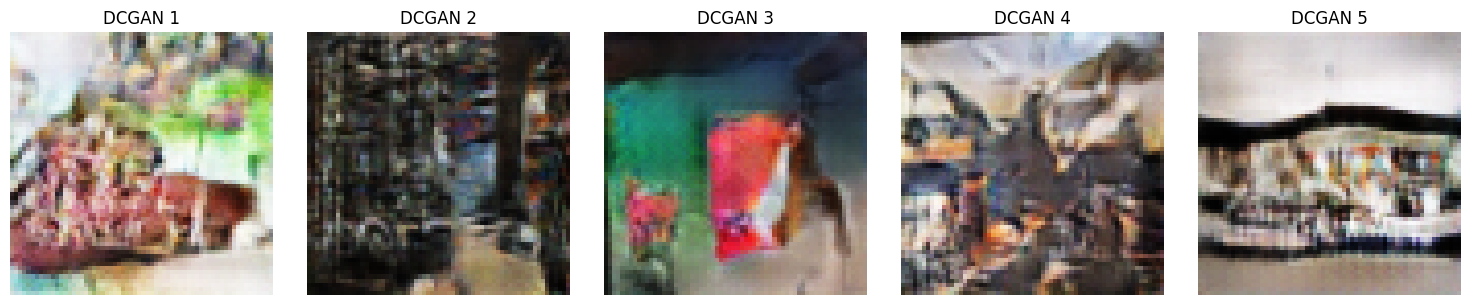

In [54]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Set the path to your generated images folder
image_folder = "dcgan_outputs/generated_fakes"

# Display the first 5 generated images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    img_path = os.path.join(image_folder, f"dcgan_gen_{i+1}.png")
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"DCGAN {i+1}")

plt.tight_layout()
plt.show()

LLM prompts
 - Explain and give generator class and discriminator class for DCGAN. 
 - how do I show 5 sample generated images.